# Atividade 3

**Membros:**

*   Giulia Monteiro Garrido (RA: 24010281)
*   Thomaz Dacorso (RA: 24012310)
*   Victor França (RA: 24010801)
*   Vitor Furuta (RA: 24008775)

### 1. Gerenciamento e Quarentena

In [1]:
import csv
import io
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go
from datetime import datetime
import threading
import time

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aliiihussain/amazon-sales-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.24M/1.24M [00:00<00:00, 104MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/aliiihussain/amazon-sales-dataset/versions/1


In [3]:
name_files = os.listdir(path)
new_path = path+"/"+name_files[0]
csv_file = open(new_path)
df = pd.read_csv(csv_file)

In [4]:
VISTAS_DIR        = "vistas_lote"
GERENCIAMENTO_DIR = "gerenciamento"

os.makedirs(VISTAS_DIR, exist_ok=True)
os.makedirs(GERENCIAMENTO_DIR, exist_ok=True)

QUARENTENA_LINHAS_PATH = os.path.join(GERENCIAMENTO_DIR, "quarentena_linhas_brutas.csv")
QUARENTENA_RESUMO_PATH = os.path.join(GERENCIAMENTO_DIR, "quarentena_linhas_por_arquivo.csv")

In [5]:
def validar_linha(row):

    if row.isnull().any():
        return "campo_nulo"

    if row["price"] <= 0 or row["total_revenue"] <= 0 or row["discounted_price"] <= 0:
        return "valor_financeiro_invalido"

    if row["quantity_sold"] < 1:
        return "quantidade_invalida"

    if not (1.0 <= row["rating"] <= 5.0):
        return "rating_fora_do_intervalo"

    if not (0 <= row["discount_percent"] <= 100):
        return "desconto_invalido"

    return None

In [6]:
motivos = df.apply(validar_linha, axis=1)
mask_validas = motivos.isna()

df_valido = df[mask_validas].copy()
df_quarentena = df[~mask_validas].copy()
df_quarentena["motivo_quarentena"] = motivos[~mask_validas]
df_quarentena["arquivo_origem"] = os.path.basename(new_path)

In [7]:
df_quarentena.to_csv(QUARENTENA_LINHAS_PATH, index=False)

resumo_quarentena = pd.DataFrame([{
    "arquivo": os.path.basename(new_path),
    "linhas_totais": len(df),
    "linhas_validas": len(df_valido),
    "linhas_quarentena": len(df_quarentena),
    "timestamp": datetime.now().isoformat()
}])

resumo_quarentena.to_csv(QUARENTENA_RESUMO_PATH, index=False)


### 2. Particionamento dos Dados

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [9]:
df['order_date'] = pd.to_datetime(df['order_date'])


In [10]:
df.groupby(df['order_date'].dt.year).size()

,0
order_date,
2022,24926
2023,25074


In [11]:
df.groupby(df['order_date'].dt.to_period('M')).size().reset_index(name='count').rename(columns={'order_date': 'year_month'})

,year_month,count
0,2022-01,2151
1,2022-02,1899
2,2022-03,2155
3,2022-04,2089
4,2022-05,2073
5,2022-06,2044
6,2022-07,2093
7,2022-08,2189
8,2022-09,2100
9,2022-10,2060


In [12]:
years = []
for i in df["order_date"]:
    if i.year not in years:
        years.append(i.year)

years.sort()
print(years)

[2022, 2023]


In [13]:
months = []
for i in df["order_date"]:
    if i.month not in months:
        months.append(i.month)
months.sort()
print(months)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [14]:
# Particionamos apenas as linhas válidas (as de quarentena ficam fora)
os.makedirs("data", exist_ok=True)

df_valido["order_date"] = pd.to_datetime(df_valido["order_date"])

##############################################################
# Separando os dados pra camada de velocidade

ultimo_mes = df_valido["order_date"].max().to_period("M")
print(f"Mês reservado para Camada de Velocidade: {ultimo_mes}")

mask_stream = df_valido["order_date"].dt.to_period("M") == ultimo_mes
df_stream = df_valido[mask_stream].copy()
df_lote = df_valido[~mask_stream].copy()

os.makedirs("dados_novos", exist_ok=True)
df_stream.to_csv("dados_novos/fonte_stream.csv", index=False)

open("dados_novos/fluxo.log", "w").close()

print(f"Lote: {len(df_lote)} linhas | Stream: {len(df_stream)} linhas")

###############################################################

# Recoletar years/months de df_lote (sem o mês reservado ao stream)
# Usar df original causava o mês do stream aparecer como pasta vazia na camada de lote
years_lote  = sorted(df_lote["order_date"].dt.year.unique())
months_lote = sorted(df_lote["order_date"].dt.month.unique())

for year in years_lote:
    folder_path_year = f"data/{year}"
    os.makedirs(folder_path_year, exist_ok=True)
    for month in months_lote:
        folder_path_month = f"{folder_path_year}/{month}"
        os.makedirs(folder_path_month, exist_ok=True)
        df_month = df_lote[(df_lote["order_date"].dt.year == year) & (df_lote["order_date"].dt.month == month)]
        if df_month.empty:
            continue  # não cria arquivo para combinações ano/mês sem dados
        df_month.to_csv(f"{folder_path_month}/data.csv", index=False)

print(f"Dados particionados em data/ ({len(df_lote)} linhas válidas)")

Mês reservado para Camada de Velocidade: 2023-12
Lote: 47937 linhas | Stream: 2063 linhas
Dados particionados em data/ (47937 linhas válidas)


### 3. Criação das Vistas de Lote a partir das Partições

In [15]:
DATA_DIR = "data"

def parcial_receita_mes(df_part):
    return (df_part.groupby(df_part["order_date"].dt.to_period("M"))
            .agg(receita_total=("total_revenue", "sum"))
            .reset_index().rename(columns={"order_date": "ano_mes"}))

def finalizar_receita_mes(parciais):
    # Filtra parciais não-vazios para evitar FutureWarning
    parciais_validos = [p for p in parciais if not p.empty]
    vista = pd.concat(parciais_validos, ignore_index=True)
    vista["ano_mes"] = vista["ano_mes"].astype(str)
    return vista

def parcial_categoria(df_part):
    return (df_part.groupby("product_category").agg(
        total_vendas =("order_id", "count"),
        receita_total=("total_revenue", "sum"),
        soma_preco=("price", "sum"),
        soma_rating=("rating", "sum"),
    ).reset_index())

def finalizar_categoria(parciais):
    parciais_validos = [p for p in parciais if not p.empty]
    v = (pd.concat(parciais_validos, ignore_index=True)
         .groupby("product_category").agg(
             total_vendas =("total_vendas","sum"),
             receita_total=("receita_total","sum"),
             soma_preco=("soma_preco","sum"),
             soma_rating=("soma_rating","sum"),
         ).reset_index())
    v["preco_medio"]= (v["soma_preco"] / v["total_vendas"]).round(2)
    v["rating_medio"]= (v["soma_rating"] / v["total_vendas"]).round(2)
    # Converte colunas numéricas explicitamente antes do round()
    v["receita_total"] = pd.to_numeric(v["receita_total"])
    v["total_vendas"] = pd.to_numeric(v["total_vendas"])
    return v.drop(columns=["soma_preco", "soma_rating"]).round(2)

def parcial_regiao(df_part):
    return (df_part.groupby("customer_region").agg(
        total_vendas =("order_id", "count"),
        receita_total=("total_revenue", "sum"),
    ).reset_index())

def finalizar_regiao(parciais):
    parciais_validos = [p for p in parciais if not p.empty]
    v = (pd.concat(parciais_validos, ignore_index=True)
         .groupby("customer_region").agg(
             total_vendas =("total_vendas","sum"),
             receita_total=("receita_total","sum"),
         ).reset_index())
    v["receita_media"] = (v["receita_total"] / v["total_vendas"]).round(2)
    return v.round(2)

def parcial_pagamento(df_part):
    return (df_part.groupby("payment_method").agg(
        total_vendas =("order_id","count"),
        receita_total=("total_revenue","sum"),
    ).reset_index())

def finalizar_pagamento(parciais):
    parciais_validos = [p for p in parciais if not p.empty]
    return (pd.concat(parciais_validos, ignore_index=True)
            .groupby("payment_method").agg(
                total_vendas =("total_vendas",  "sum"),
                receita_total=("receita_total", "sum"),
            ).reset_index().round(2))

def parcial_desconto(df_part):
    return (df_part.groupby("product_category").agg(
        total_vendas=("order_id", "count"),
        soma_desconto=("discount_percent", "sum"),
        soma_preco_desc=("discounted_price", "sum"),
        soma_qtd=("quantity_sold", "sum"),
    ).reset_index())

def finalizar_desconto(parciais):
    parciais_validos = [p for p in parciais if not p.empty]
    v = (pd.concat(parciais_validos, ignore_index=True)
         .groupby("product_category").agg(
             total_vendas=("total_vendas","sum"),
             soma_desconto=("soma_desconto","sum"),
             soma_preco_desc=("soma_preco_desc","sum"),
             soma_qtd=("soma_qtd","sum"),
         ).reset_index())
    # Converte para numérico antes de dividir/arredondar
    v["soma_desconto"] = pd.to_numeric(v["soma_desconto"])
    v["soma_preco_desc"] = pd.to_numeric(v["soma_preco_desc"])
    v["soma_qtd"] = pd.to_numeric(v["soma_qtd"])
    v["total_vendas"] = pd.to_numeric(v["total_vendas"])
    v["desconto_medio"]= (v["soma_desconto"] / v["total_vendas"]).round(2)
    v["preco_desc_medio"] = (v["soma_preco_desc"] / v["total_vendas"]).round(2)
    v["qtd_media"]= (v["soma_qtd"] / v["total_vendas"]).round(2)
    # Mantém total_vendas para permitir média ponderada na combinação com TR
    return v[["product_category", "total_vendas", "desconto_medio", "preco_desc_medio", "qtd_media"]]

def parcial_dia(df_part):
    return (df_part.groupby(df_part["order_date"].dt.date).agg(
        total_vendas =("order_id", "count"),
        receita_total=("total_revenue", "sum"),
    ).reset_index().rename(columns={"order_date": "data"}))

def finalizar_dia(parciais):
    parciais_validos = [p for p in parciais if not p.empty]
    return pd.concat(parciais_validos, ignore_index=True).round(2)

VISTAS = [
    {"arquivo": "receita_por_mes.csv","parcial": parcial_receita_mes,"finalizar": finalizar_receita_mes},
    {"arquivo": "vendas_por_categoria.csv","parcial": parcial_categoria,"finalizar": finalizar_categoria},
    {"arquivo": "vendas_por_regiao.csv","parcial": parcial_regiao,"finalizar": finalizar_regiao},
    {"arquivo": "vendas_por_pagamento.csv","parcial": parcial_pagamento,"finalizar": finalizar_pagamento},
    {"arquivo": "desconto_por_categoria.csv", "parcial": parcial_desconto,"finalizar": finalizar_desconto},
    {"arquivo": "vendas_por_dia.csv","parcial": parcial_dia,"finalizar": finalizar_dia},
]

def iterar_particoes(data_dir):
    for ano in sorted(os.listdir(data_dir)):
        ano_path = os.path.join(data_dir, ano)
        if not os.path.isdir(ano_path):
            continue
        for mes in sorted(os.listdir(ano_path)):
            arq = os.path.join(ano_path, mes, "data.csv")
            if os.path.exists(arq):
                yield arq

def construir_vistas_dos_lotes(data_dir=DATA_DIR):
    os.makedirs(VISTAS_DIR, exist_ok=True)

    parciais = {v["arquivo"]: [] for v in VISTAS}

    arquivos_processados = 0
    linhas_totais = 0

    # Percorre cada partição e aplica as parciais
    for arq in iterar_particoes(data_dir):
        df_part = pd.read_csv(arq)
        df_part["order_date"] = pd.to_datetime(df_part["order_date"])
        arquivos_processados += 1
        linhas_totais += len(df_part)

        for v in VISTAS:
            parciais[v["arquivo"]].append(v["parcial"](df_part))

    # Finaliza cada vista e salva em CSV
    for v in VISTAS:
        vista_final = v["finalizar"](parciais[v["arquivo"]])
        vista_final.to_csv(os.path.join(VISTAS_DIR, v["arquivo"]), index=False)
        print(f"{v['arquivo']}")

    print(f"\nProcessadas {arquivos_processados} partições ({linhas_totais} linhas)")


construir_vistas_dos_lotes()

receita_por_mes.csv
vendas_por_categoria.csv
vendas_por_regiao.csv
vendas_por_pagamento.csv
desconto_por_categoria.csv
vendas_por_dia.csv

Processadas 24 partições (47937 linhas)


In [16]:
v_receita = pd.read_csv(os.path.join(VISTAS_DIR, "receita_por_mes.csv"))
v_categoria = pd.read_csv(os.path.join(VISTAS_DIR, "vendas_por_categoria.csv"))
v_regiao = pd.read_csv(os.path.join(VISTAS_DIR, "vendas_por_regiao.csv"))
v_pagamento = pd.read_csv(os.path.join(VISTAS_DIR, "vendas_por_pagamento.csv"))
v_desconto = pd.read_csv(os.path.join(VISTAS_DIR, "desconto_por_categoria.csv"))
v_dia = pd.read_csv(os.path.join(VISTAS_DIR, "vendas_por_dia.csv"))

### 4. Camada de Velocidade

#### Cenário e Janela Temporal

Os dados do **último mês completo** do dataset (`df_stream`) simulam registros que ainda não foram incorporados à Camada de Lote — situação comum em sistemas reais onde o processamento batch ocorre com atraso (ex.: processamento noturno ou semanal). Enquanto esses dados não entram no lote, a Camada de Velocidade é responsável por suprir essa lacuna temporal.

**Intervalo da janela de velocidade:** do primeiro ao último dia do último mês do dataset, identificado automaticamente como `df_valido['order_date'].max().to_period('M')`.

#### Projeto das Vistas de Tempo Real

Para cada nova linha que chega pelo `fluxo.log`, seis **acumuladores em memória** (`VISTAS_TR`) são atualizados de forma incremental e thread-safe (com `threading.Lock`):

| Vista TR | Acumula | Finaliza como |
|---|---|---|
| `receita_por_mes` | soma de `total_revenue` por período | receita total do mês |
| `vendas_por_categoria` | contagem, soma receita, soma preço, soma rating | médias ponderadas |
| `vendas_por_regiao` | contagem, soma receita | receita média por região |
| `vendas_por_pagamento` | contagem, soma receita | totais por método |
| `desconto_por_categoria` | contagem, soma desconto%, soma preço desc., soma qtd | médias ponderadas |
| `vendas_por_dia` | contagem, soma receita por dia | totais diários |

As vistas são persistidas em `vistas_tempo_real/` a cada nova linha processada, garantindo que um snapshot recente esteja sempre disponível em disco.

#### Modo de Combinação Lote + Tempo Real

Cada função de consulta (Seção 4a) opera em duas etapas:
1. **Lê a vista de lote** do CSV em `vistas_lote/` (dados históricos completos, excluindo o último mês).
2. **Mescla com a vista TR** em memória (dados do último mês recebidos até agora via stream).

A combinação é sempre **aditiva para contagens e somas** (ex.: `total_vendas += tr_vendas`). Para médias (preço, rating, desconto), aplica-se **média ponderada** pelo número de registros de cada fonte, garantindo resultado matematicamente correto.

Para a vista `desconto_por_categoria`, a camada de lote não persiste `total_vendas` — portanto a vista TR armazena as **somas brutas** (`soma_desconto`, `soma_preco_desc`, `soma_qtd`) além de `total_vendas`, permitindo recalcular a média ponderada exata na consulta combinada.

In [17]:

VISTAS_TR_DIR = "vistas_tempo_real"
os.makedirs(VISTAS_TR_DIR, exist_ok=True)

lock_vistas = threading.Lock()

# Variável global de controle (declarada explicitamente como global)
finaliza_laco = False

COLUNAS = ["order_id","order_date","product_id","product_category","price",
           "discount_percent","quantity_sold","customer_region",
           "payment_method","rating","review_count","discounted_price","total_revenue"]


def _vistas_tr_vazias():
    return {
        "receita_por_mes": {},
        "vendas_por_categoria": {},
        "vendas_por_regiao": {},
        "vendas_por_pagamento": {},
        "desconto_por_categoria": {},
        "vendas_por_dia": {}
    }

VISTAS_TR = _vistas_tr_vazias()


def stream_dados(arquivo):
    """Gera linhas novas do arquivo de fluxo. Usa `global finaliza_laco`
    para leitura correta da variável de controle compartilhada."""
    global finaliza_laco  #global para leitura segura
    with open(arquivo, "r") as arq:
        while not finaliza_laco:
            linha = arq.readline().strip()
            if not linha:
                time.sleep(1)
                continue
            yield linha



def parsear_linha(linha):

    try:
        reader = csv.reader(io.StringIO(linha))
        valores = next(reader)
    except Exception:
        return None

    if len(valores) != len(COLUNAS):
        return None

    try:
        reg = dict(zip(COLUNAS, valores))
        reg["order_date"] = pd.to_datetime(reg["order_date"])
        reg["price"] = float(reg["price"])
        reg["discount_percent"] = int(reg["discount_percent"])
        reg["quantity_sold"] = int(reg["quantity_sold"])
        reg["rating"] = float(reg["rating"])
        reg["discounted_price"] = float(reg["discounted_price"])
        reg["total_revenue"] = float(reg["total_revenue"])
    except (ValueError, KeyError):
        return None

    return reg


def atualizar_vistas_tr(reg):
    with lock_vistas:
        # 1. receita_por_mes
        chave = str(reg["order_date"].to_period("M"))
        VISTAS_TR["receita_por_mes"][chave] = VISTAS_TR["receita_por_mes"].get(chave, 0) + reg["total_revenue"]

        # 2. vendas_por_categoria
        cat = reg["product_category"]
        v = VISTAS_TR["vendas_por_categoria"].setdefault(cat, {"total_vendas":0,"receita":0,"soma_preco":0,"soma_rating":0})
        v["total_vendas"] += 1
        v["receita"] += reg["total_revenue"]
        v["soma_preco"] += reg["price"]
        v["soma_rating"] += reg["rating"]

        # 3. vendas_por_regiao
        reg_key = reg["customer_region"]
        v = VISTAS_TR["vendas_por_regiao"].setdefault(reg_key, {"total_vendas": 0, "receita_total": 0})
        v["total_vendas"] += 1
        v["receita_total"] += reg["total_revenue"]

        # 4. vendas_por_pagamento
        pag = reg["payment_method"]
        v = VISTAS_TR["vendas_por_pagamento"].setdefault(pag, {"total_vendas": 0, "receita_total": 0})
        v["total_vendas"] += 1
        v["receita_total"] += reg["total_revenue"]

        # 5. desconto_por_categoria
        cat = reg["product_category"]
        v = VISTAS_TR["desconto_por_categoria"].setdefault(cat, {"total_vendas": 0, "soma_desconto": 0,"soma_preco_desc": 0, "soma_qtd": 0})
        v["total_vendas"] += 1
        v["soma_desconto"] += reg["discount_percent"]
        v["soma_preco_desc"] += reg["discounted_price"]
        v["soma_qtd"] += reg["quantity_sold"]

        # 6. vendas_por_dia
        dia = reg["order_date"].date()
        v = VISTAS_TR["vendas_por_dia"].setdefault(dia, {"total_vendas":0,"receita":0})
        v["total_vendas"] += 1
        v["receita"] += reg["total_revenue"]



def persistir_vistas_tr():
    """Salva um snapshot das vistas de tempo real em CSV."""
    with lock_vistas:
        # receita_por_mes
        pd.DataFrame(
            list(VISTAS_TR["receita_por_mes"].items()),
            columns=["ano_mes", "receita_total"]
        ).to_csv(os.path.join(VISTAS_TR_DIR, "receita_por_mes_tr.csv"), index=False)

        # vendas_por_categoria
        rows_cat = []
        for cat, vals in VISTAS_TR["vendas_por_categoria"].items():
            n = vals["total_vendas"]
            rows_cat.append({
                "product_category": cat,
                "total_vendas": n,
                "receita_total": round(vals["receita"], 2),
                "preco_medio": round(vals["soma_preco"] / n, 2) if n else 0,
                "rating_medio": round(vals["soma_rating"] / n, 2) if n else 0,
            })
        pd.DataFrame(rows_cat).to_csv(
            os.path.join(VISTAS_TR_DIR, "vendas_por_categoria_tr.csv"), index=False)

        # vendas_por_regiao
        rows_reg = []
        for reg_key, vals in VISTAS_TR["vendas_por_regiao"].items():
            n = vals["total_vendas"]
            rows_reg.append({
                "customer_region": reg_key,
                "total_vendas": n,
                "receita_total": round(vals["receita_total"], 2),
                "receita_media": round(vals["receita_total"] / n, 2) if n else 0,
            })
        pd.DataFrame(rows_reg).to_csv(
            os.path.join(VISTAS_TR_DIR, "vendas_por_regiao_tr.csv"), index=False)

        # vendas_por_pagamento
        rows_pag = []
        for pag, vals in VISTAS_TR["vendas_por_pagamento"].items():
            rows_pag.append({
                "payment_method": pag,
                "total_vendas": vals["total_vendas"],
                "receita_total": round(vals["receita_total"], 2),
            })
        pd.DataFrame(rows_pag).to_csv(
            os.path.join(VISTAS_TR_DIR, "vendas_por_pagamento_tr.csv"), index=False)

        # desconto_por_categoria
        rows_desc = []
        for cat, vals in VISTAS_TR["desconto_por_categoria"].items():
            n = vals["total_vendas"]
            rows_desc.append({
                "product_category": cat,
                "desconto_medio": round(vals["soma_desconto"] / n, 2) if n else 0,
                "preco_desc_medio": round(vals["soma_preco_desc"] / n, 2) if n else 0,
                "qtd_media": round(vals["soma_qtd"] / n, 2) if n else 0,
            })
        pd.DataFrame(rows_desc).to_csv(
            os.path.join(VISTAS_TR_DIR, "desconto_por_categoria_tr.csv"), index=False)

        # vendas_por_dia
        rows_dia = []
        for dia, vals in VISTAS_TR["vendas_por_dia"].items():
            rows_dia.append({
                "data": str(dia),
                "total_vendas": vals["total_vendas"],
                "receita_total": round(vals["receita"], 2),
            })
        pd.DataFrame(rows_dia).to_csv(
            os.path.join(VISTAS_TR_DIR, "vendas_por_dia_tr.csv"), index=False)


def monitora_linhas(arquivo):
    print('inicializando monitoramento')

    for nova_linha in stream_dados(arquivo):
        reg = parsear_linha(nova_linha)

        if reg is None:
            print(f"[quarentena] {nova_linha}")
            continue

        atualizar_vistas_tr(reg)
        persistir_vistas_tr()   # persiste a cada nova linha processada
        print(f"processado: {reg['order_id']} | {reg['order_date'].date()}")

    print('finalizando monitoramento')

In [18]:
finaliza_laco = False
VISTAS_TR.update(_vistas_tr_vazias())   # zera acumuladores

t = threading.Thread(target=monitora_linhas, args=("dados_novos/fluxo.log",))
t.start()
print("Thread ativa:", t.is_alive())

inicializando monitoramentoThread ativa: True



In [19]:
# ── Simulação incremental: envia N linhas ao fluxo.log ──────────────────────
# Use esta célula para simular chegada gradual de dados (ex.: durante apresentação).
# A thread precisa estar ativa (célula anterior). Ajuste N_LINHAS conforme necessário.

N_LINHAS = 20   # alterar aqui

df_fonte = pd.read_csv("dados_novos/fonte_stream.csv")
with open("dados_novos/fluxo.log", "a") as f:
    for _, row in df_fonte.head(N_LINHAS).iterrows():
        linha = ",".join(str(v) for v in row.values)
        f.write(linha + "\n")

print(f"{N_LINHAS} linhas enviadas ao fluxo.log")

20 linhas enviadas ao fluxo.log


In [20]:
# Encerra a thread de monitoramento
print("antes :", t.is_alive())
finaliza_laco = True
time.sleep(1.5)
print("depois:", t.is_alive())

antes : True
finalizando monitoramento
depois: False


In [ ]:
# ── Ingestão completa do stream (popula vistas_tempo_real/) ─────────────────
# Processa TODAS as linhas de fonte_stream.csv de uma vez:
# reinicia os acumuladores TR, envia todas as linhas ao fluxo.log e
# aguarda a thread terminar de processar antes de prosseguir.
# Execute esta célula antes das consultas combinadas para garantir que
# vistas_tempo_real/ esteja populada com todos os dados do stream.

# 1. Encerrar thread anterior se ainda estiver ativa
if "t" in dir() and t.is_alive():
    finaliza_laco = True
    t.join(timeout=3)

# 2. Reiniciar acumuladores e fluxo
finaliza_laco = False
VISTAS_TR.update(_vistas_tr_vazias())
open("dados_novos/fluxo.log", "w").close()  # limpa o log

# 3. Iniciar thread de monitoramento
t = threading.Thread(target=monitora_linhas, args=("dados_novos/fluxo.log",))
t.start()

# 4. Enviar todas as linhas do fonte_stream ao fluxo.log
df_fonte = pd.read_csv("dados_novos/fonte_stream.csv")
with open("dados_novos/fluxo.log", "a") as f:
    for _, row in df_fonte.iterrows():
        linha = ",".join(str(v) for v in row.values)
        f.write(linha + "\n")

print(f"{len(df_fonte)} linhas enviadas ao fluxo.log")

# 5. Aguardar processamento: espera até as vistas TR terem todas as linhas
import time as _time
timeout = 60  # segundos máximos de espera
inicio = _time.time()
while _time.time() - inicio < timeout:
    with lock_vistas:
        total_tr = sum(
            (v["total_vendas"] if isinstance(v, dict) else 0)
            for v in VISTAS_TR["vendas_por_dia"].values()
        )
    if total_tr >= len(df_fonte):
        break
    _time.sleep(0.5)

# 6. Encerrar thread
finaliza_laco = True
t.join(timeout=3)

print(f"Stream concluído: {total_tr} registros nas vistas TR")
print(f"Thread ativa: {t.is_alive()}")

In [21]:
def snapshot_tr(nome):
    with lock_vistas:
        return {k: (dict(v) if isinstance(v, dict) else v)
                for k, v in VISTAS_TR[nome].items()}

### 4a. Funções de Consulta Combinada (Lote + Tempo Real)

Cada função abaixo combina a vista de lote (arquivo CSV salvo) com o estado
atual das Vistas de Tempo Real para produzir o resultado completo e atualizado
— exigido pelo item 3 da atividade.

In [22]:


def consulta_receita_por_mes():
    lote = pd.read_csv("vistas_lote/receita_por_mes.csv")
    lote_dict = dict(zip(lote["ano_mes"], lote["receita_total"]))

    with lock_vistas:
        tr = dict(VISTAS_TR["receita_por_mes"])

    combinado = {**lote_dict}
    for mes, valor in tr.items():
        combinado[mes] = combinado.get(mes, 0) + valor

    return (pd.DataFrame(list(combinado.items()), columns=["ano_mes","receita_total"])
              .sort_values("ano_mes").reset_index(drop=True))


def consulta_vendas_por_categoria():
    lote = pd.read_csv("vistas_lote/vendas_por_categoria.csv")

    with lock_vistas:
        tr_snap = {k: dict(v) for k, v in VISTAS_TR["vendas_por_categoria"].items()}

    lote = lote.set_index("product_category")
    for cat, vals in tr_snap.items():
        if cat in lote.index:
            lote.at[cat, "total_vendas"]  += vals["total_vendas"]
            lote.at[cat, "receita_total"] += vals["receita"]
            soma_preco_nova = lote.at[cat, "preco_medio"] * (lote.at[cat, "total_vendas"] - vals["total_vendas"]) + vals["soma_preco"]
            soma_rating_nova = lote.at[cat, "rating_medio"] * (lote.at[cat, "total_vendas"] - vals["total_vendas"]) + vals["soma_rating"]
            lote.at[cat, "preco_medio"]   = round(soma_preco_nova  / lote.at[cat, "total_vendas"], 2)
            lote.at[cat, "rating_medio"]  = round(soma_rating_nova / lote.at[cat, "total_vendas"], 2)
        else:
            n = vals["total_vendas"]
            lote.loc[cat] = {
                "total_vendas":  n,
                "receita_total": round(vals["receita"], 2),
                "preco_medio":   round(vals["soma_preco"] / n, 2) if n else 0,
                "rating_medio":  round(vals["soma_rating"] / n, 2) if n else 0,
            }
    return lote.reset_index().round(2)


def consulta_vendas_por_regiao():
    lote = pd.read_csv("vistas_lote/vendas_por_regiao.csv")

    with lock_vistas:
        tr_snap = {k: dict(v) for k, v in VISTAS_TR["vendas_por_regiao"].items()}

    lote = lote.set_index("customer_region")
    for reg_key, vals in tr_snap.items():
        if reg_key in lote.index:
            lote.at[reg_key, "total_vendas"]  += vals["total_vendas"]
            lote.at[reg_key, "receita_total"] += vals["receita_total"]
        else:
            lote.loc[reg_key] = {"total_vendas": vals["total_vendas"],
                                 "receita_total": vals["receita_total"],
                                 "receita_media": 0}
    lote["receita_media"] = (lote["receita_total"] / lote["total_vendas"]).round(2)
    return lote.reset_index().round(2)


def consulta_vendas_por_pagamento():
    lote = pd.read_csv("vistas_lote/vendas_por_pagamento.csv")

    with lock_vistas:
        tr_snap = {k: dict(v) for k, v in VISTAS_TR["vendas_por_pagamento"].items()}

    lote = lote.set_index("payment_method")
    for pag, vals in tr_snap.items():
        if pag in lote.index:
            lote.at[pag, "total_vendas"]  += vals["total_vendas"]
            lote.at[pag, "receita_total"] += vals["receita_total"]
        else:
            lote.loc[pag] = {"total_vendas": vals["total_vendas"],
                             "receita_total": vals["receita_total"]}
    return lote.reset_index().round(2)


def consulta_desconto_por_categoria():
    lote = pd.read_csv("vistas_lote/desconto_por_categoria.csv")

    with lock_vistas:
        tr_snap = {k: dict(v) for k, v in VISTAS_TR["desconto_por_categoria"].items()}

    # Combinação com média ponderada correta:
    # A vista de lote agora persiste total_vendas, permitindo ponderar as médias
    # pela quantidade real de registros de cada fonte (lote vs. TR).
    lote = lote.set_index("product_category")
    for cat, vals in tr_snap.items():
        n_tr = vals["total_vendas"]
        if n_tr == 0:
            continue
        if cat in lote.index:
            n_lote = lote.at[cat, "total_vendas"]
            n_total = n_lote + n_tr
            # Recalcula médias ponderadas: (media_lote * n_lote + soma_tr) / n_total
            lote.at[cat, "desconto_medio"]   = round((lote.at[cat, "desconto_medio"]   * n_lote + vals["soma_desconto"])   / n_total, 2)
            lote.at[cat, "preco_desc_medio"] = round((lote.at[cat, "preco_desc_medio"] * n_lote + vals["soma_preco_desc"]) / n_total, 2)
            lote.at[cat, "qtd_media"]        = round((lote.at[cat, "qtd_media"]        * n_lote + vals["soma_qtd"])        / n_total, 2)
            lote.at[cat, "total_vendas"]     = n_total
        else:
            lote.loc[cat] = {
                "total_vendas":     n_tr,
                "desconto_medio":   round(vals["soma_desconto"]   / n_tr, 2),
                "preco_desc_medio": round(vals["soma_preco_desc"] / n_tr, 2),
                "qtd_media":        round(vals["soma_qtd"]        / n_tr, 2),
            }
    # Remove total_vendas da saída final (coluna auxiliar de combinação)
    return lote.reset_index().drop(columns=["total_vendas"])


def consulta_vendas_por_dia():
    lote = pd.read_csv("vistas_lote/vendas_por_dia.csv")

    with lock_vistas:
        tr_snap = {str(k): dict(v) for k, v in VISTAS_TR["vendas_por_dia"].items()}

    lote = lote.set_index("data")
    for dia, vals in tr_snap.items():
        if dia in lote.index:
            lote.at[dia, "total_vendas"]  += vals["total_vendas"]
            lote.at[dia, "receita_total"] += vals["receita"]
        else:
            lote.loc[dia] = {"total_vendas": vals["total_vendas"],
                             "receita_total": round(vals["receita"], 2)}
    return lote.reset_index().sort_values("data").reset_index(drop=True).round(2)

### 5. Consultas (Lote + Tempo Real combinados)

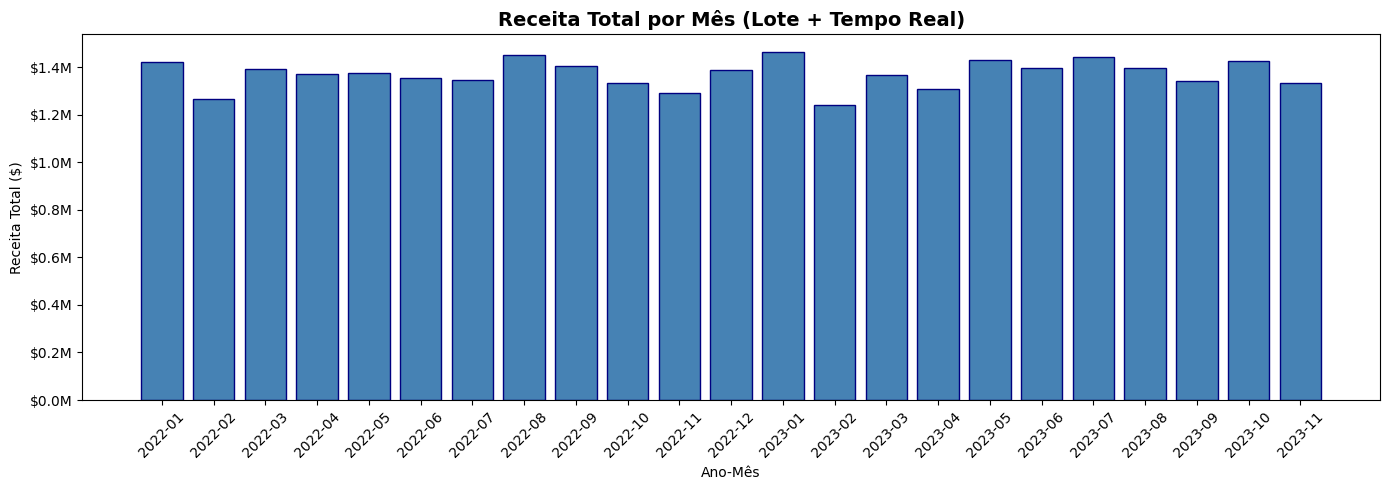

In [23]:

rc_mes = consulta_receita_por_mes()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(rc_mes['ano_mes'], rc_mes['receita_total'], color='steelblue', edgecolor='navy')
ax.set_title('Receita Total por Mês (Lote + Tempo Real)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano-Mês')
ax.set_ylabel('Receita Total ($)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

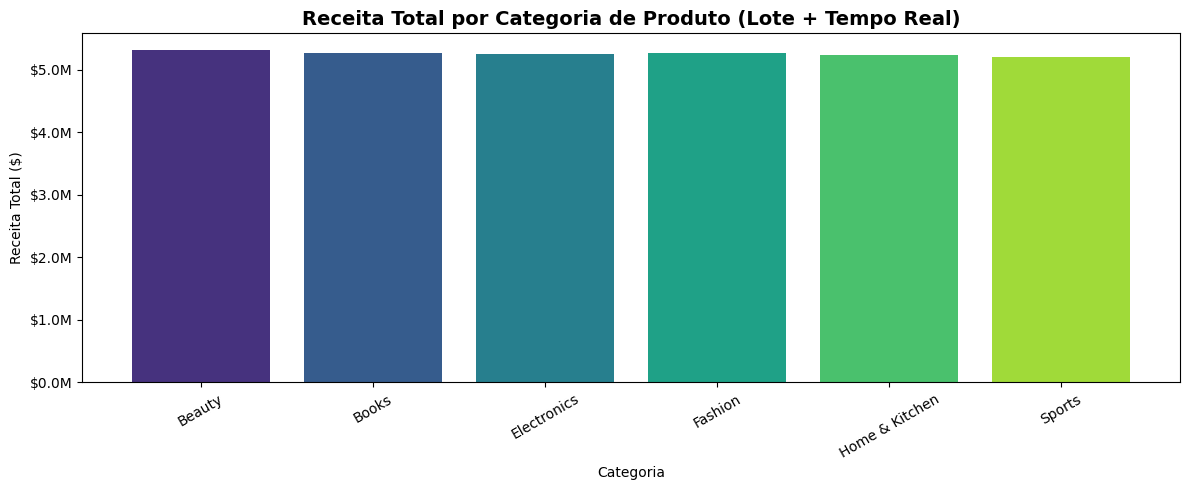

In [24]:
rc_cat = consulta_vendas_por_categoria()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(rc_cat['product_category'], rc_cat['receita_total'],
       color=sns.color_palette('viridis', len(rc_cat)))
ax.set_title('Receita Total por Categoria de Produto (Lote + Tempo Real)', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoria')
ax.set_ylabel('Receita Total ($)')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

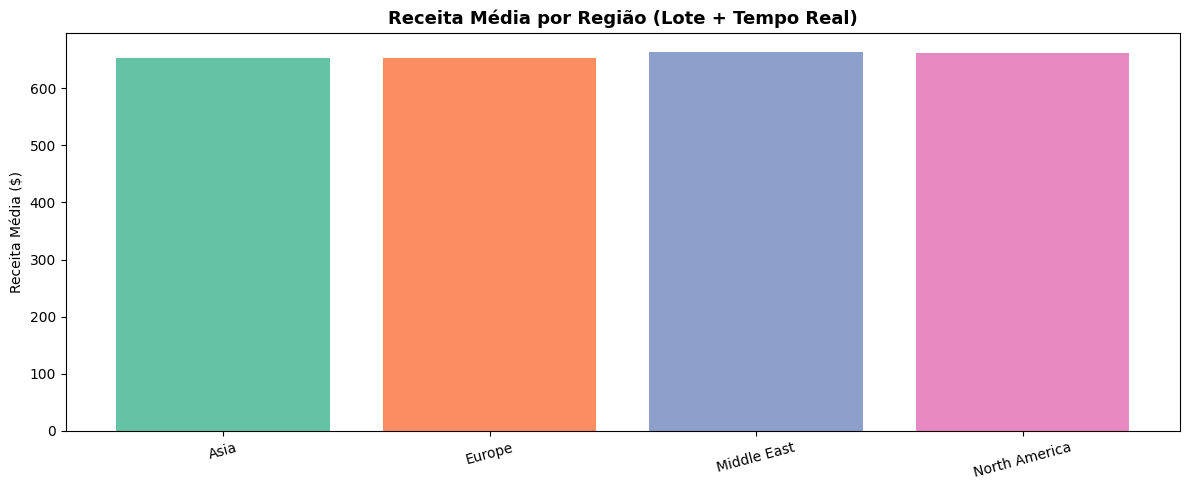

In [25]:
rc_reg = consulta_vendas_por_regiao()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(rc_reg['customer_region'], rc_reg['receita_media'],
       color=sns.color_palette('Set2', len(rc_reg)))
ax.set_title('Receita Média por Região (Lote + Tempo Real)', fontsize=13, fontweight='bold')
ax.set_ylabel('Receita Média ($)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

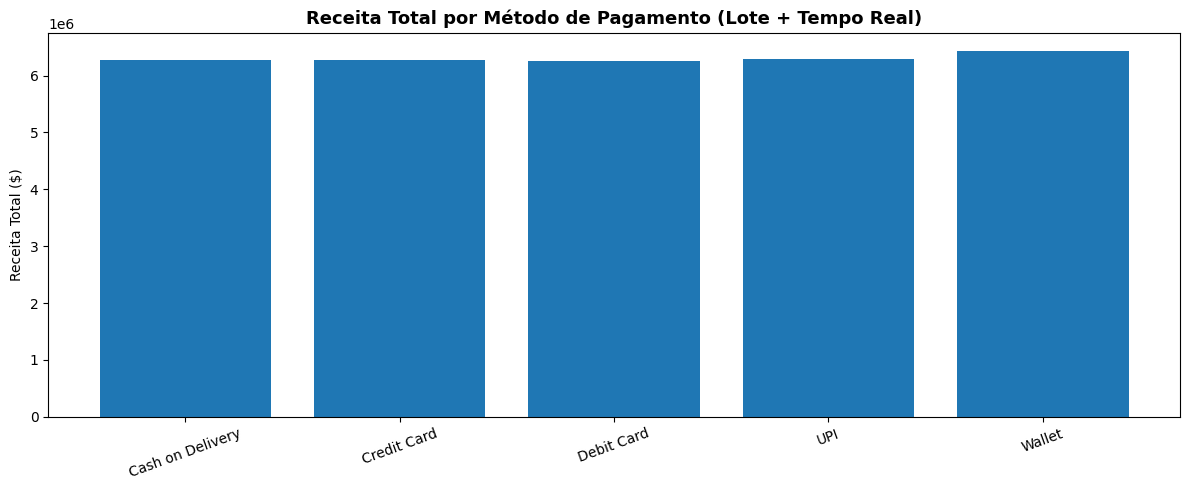

In [26]:
rc_pag = consulta_vendas_por_pagamento()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(rc_pag['payment_method'], rc_pag['receita_total'])
ax.set_title('Receita Total por Método de Pagamento (Lote + Tempo Real)', fontsize=13, fontweight='bold')
ax.set_ylabel('Receita Total ($)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

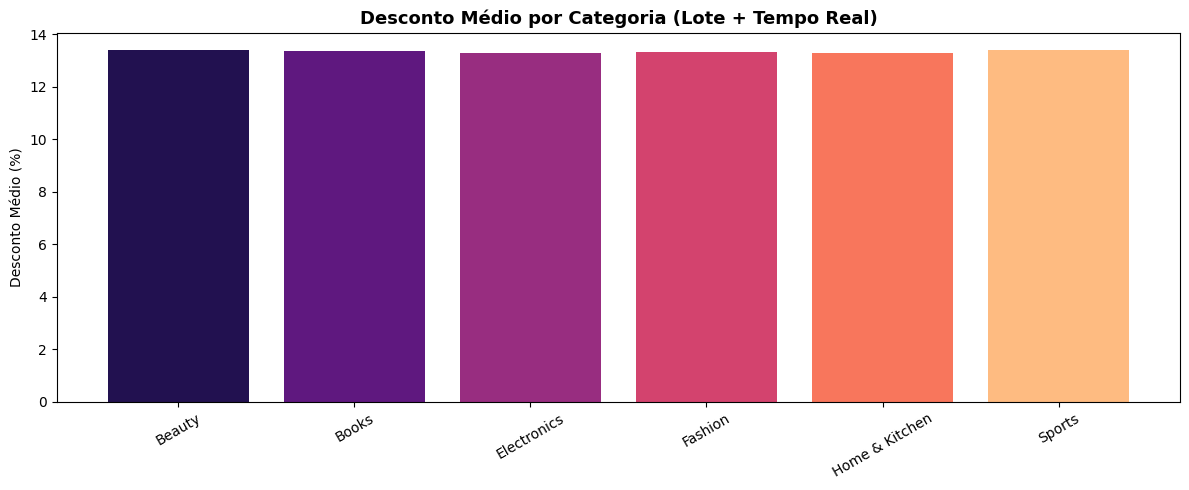

In [27]:
rc_desc = consulta_desconto_por_categoria()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(rc_desc['product_category'], rc_desc['desconto_medio'],
       color=sns.color_palette('magma', len(rc_desc)))
ax.set_title('Desconto Médio por Categoria (Lote + Tempo Real)', fontsize=13, fontweight='bold')
ax.set_ylabel('Desconto Médio (%)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

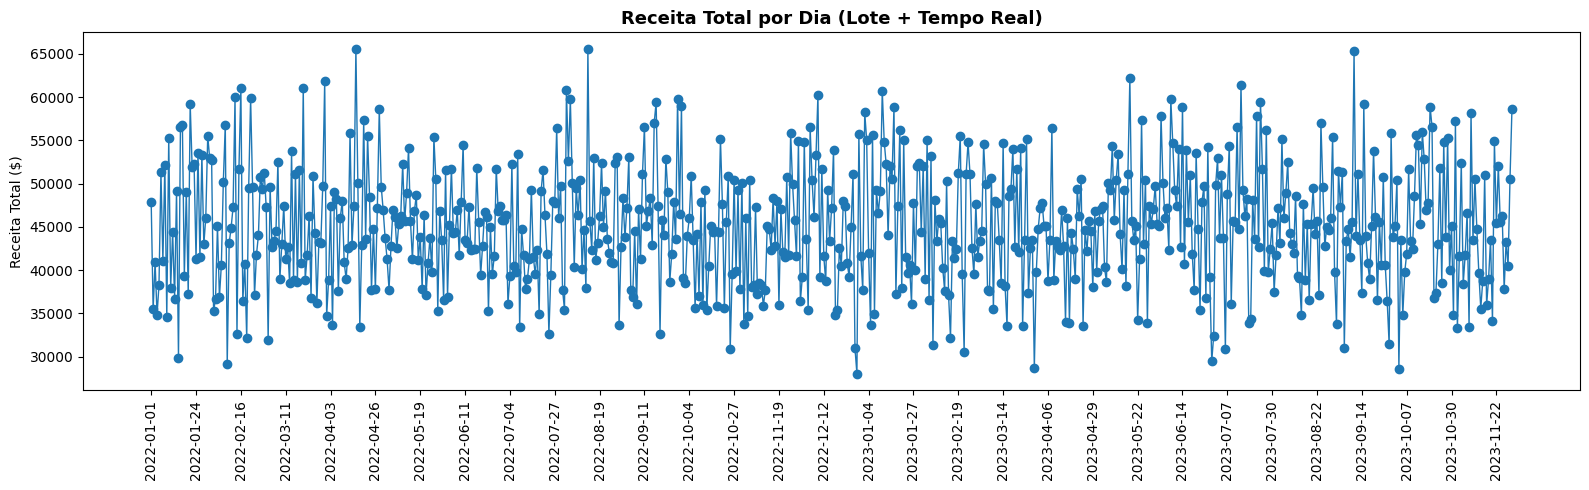

In [28]:
rc_dia = consulta_vendas_por_dia()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(rc_dia['data'].astype(str), rc_dia['receita_total'], marker='o', linewidth=1)
ax.set_title('Receita Total por Dia (Lote + Tempo Real)', fontsize=13, fontweight='bold')
ax.set_ylabel('Receita Total ($)')
ax.tick_params(axis='x', rotation=90)
# Mostrar apenas alguns ticks para não poluir
step = max(1, len(rc_dia) // 30)
ax.set_xticks(ax.get_xticks()[::step])
plt.tight_layout()
plt.show()